In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('GermanCredit.csv')

print("Taille du dataset :", df.shape)
df.head(10)

Taille du dataset : (1000, 21)


,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,... < 100 DM,6,critical account/other credits existing,domestic appliances,1169,unknown/no savings account,... >= 7 years,4,male : single,none,...,real estate,67,none,own,2,skilled employee/official,1,yes,yes,1
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee/official,1,no,yes,0
2,no checking account,12,critical account/other credits existing,retraining,2096,... < 100 DM,4 <= ... < 7 years,2,male : single,none,...,real estate,49,none,own,1,unskilled - resident,2,no,yes,1
3,... < 100 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,guarantor,...,building society savings agreement/life insurance,45,none,for free,1,skilled employee/official,2,no,yes,1
4,... < 100 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,none,...,unknown/no property,53,none,for free,2,skilled employee/official,2,no,yes,0
5,no checking account,36,existing credits paid back duly till now,retraining,9055,unknown/no savings account,1 <= ... < 4 years,2,male : single,none,...,unknown/no property,35,none,for free,1,unskilled - resident,2,yes,yes,1
6,no checking account,24,existing credits paid back duly till now,radio/television,2835,500 <= ... < 1000 DM,... >= 7 years,3,male : single,none,...,building society savings agreement/life insurance,53,none,own,1,skilled employee/official,1,no,yes,1
7,0 <= ... < 200 DM,36,existing credits paid back duly till now,car (used),6948,... < 100 DM,1 <= ... < 4 years,2,male : single,none,...,car or other,35,none,rent,1,management/self-employed/highly qualified empl...,1,yes,yes,1
8,no checking account,12,existing credits paid back duly till now,domestic appliances,3059,... >= 1000 DM,4 <= ... < 7 years,2,male : divorced/separated,none,...,real estate,61,none,own,1,unskilled - resident,1,no,yes,1
9,0 <= ... < 200 DM,30,critical account/other credits existing,car (new),5234,... < 100 DM,unemployed,4,male : married/widowed,none,...,car or other,28,none,own,2,management/self-employed/highly qualified empl...,1,no,yes,0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   status                   1000 non-null   str  
 1   duration                 1000 non-null   int64
 2   credit_history           1000 non-null   str  
 3   purpose                  1000 non-null   str  
 4   amount                   1000 non-null   int64
 5   savings                  1000 non-null   str  
 6   employment_duration      1000 non-null   str  
 7   installment_rate         1000 non-null   int64
 8   personal_status_sex      1000 non-null   str  
 9   other_debtors            1000 non-null   str  
 10  present_residence        1000 non-null   int64
 11  property                 1000 non-null   str  
 12  age                      1000 non-null   int64
 13  other_installment_plans  1000 non-null   str  
 14  housing                  1000 non-null   str  
 15  number_credits  

In [6]:
# La colonne cible : combien de bons et de mauvais clients ?
df['credit_risk'].value_counts()


credit_risk
1    700
0    300
Name: count, dtype: int64

In [8]:
# Statistiques des colonnes numériques
df.describe()

,duration,amount,installment_rate,present_residence,age,number_credits,people_liable,credit_risk
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,0.700000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,0.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,0.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,1.000000


In [9]:
# Quelles colonnes sont du texte (catégorielles) ?
df.dtypes

status                       str
duration                   int64
credit_history               str
purpose                      str
amount                     int64
savings                      str
employment_duration          str
installment_rate           int64
personal_status_sex          str
other_debtors                str
present_residence          int64
property                     str
age                        int64
other_installment_plans      str
housing                      str
number_credits             int64
job                          str
people_liable              int64
telephone                    str
foreign_worker               str
credit_risk                int64
dtype: object

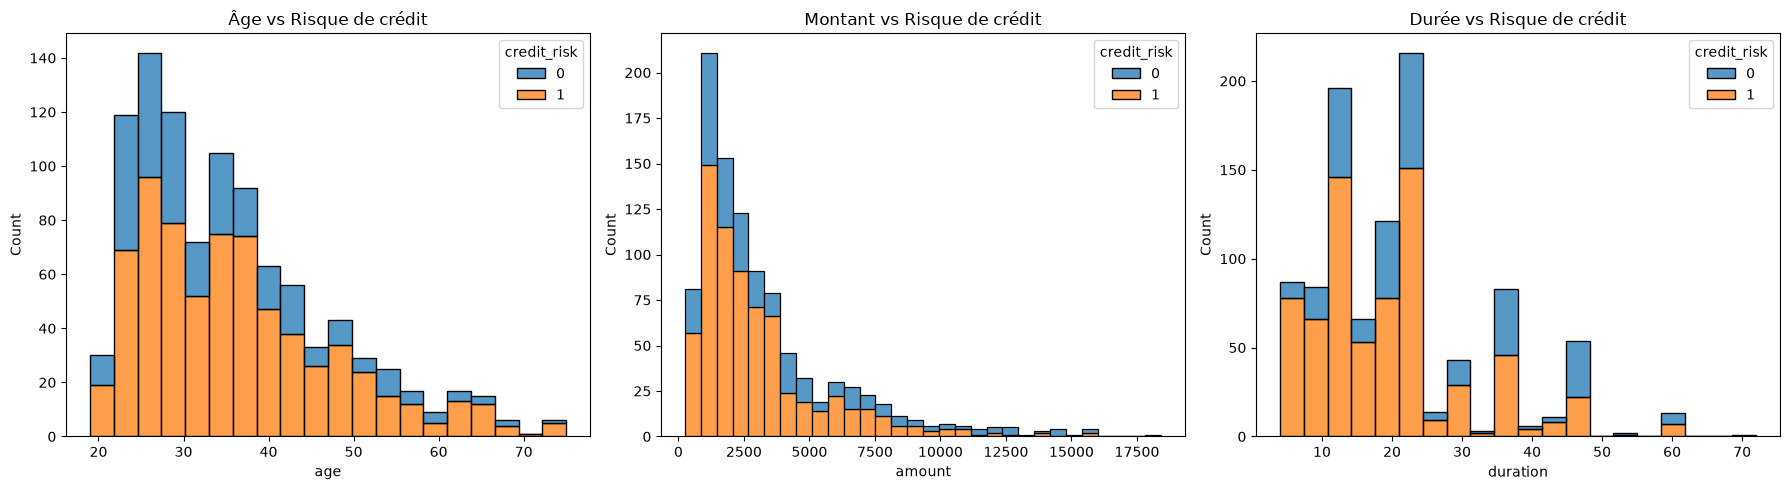

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=df, x='age', hue='credit_risk', multiple='stack', bins=20, ax=axes[0])
axes[0].set_title('Âge vs Risque de crédit')

sns.histplot(data=df, x='amount', hue='credit_risk', multiple='stack', bins=30, ax=axes[1])
axes[1].set_title('Montant vs Risque de crédit')

sns.histplot(data=df, x='duration', hue='credit_risk', multiple='stack', bins=20, ax=axes[2])
axes[2].set_title('Durée vs Risque de crédit')

plt.tight_layout()
plt.show()

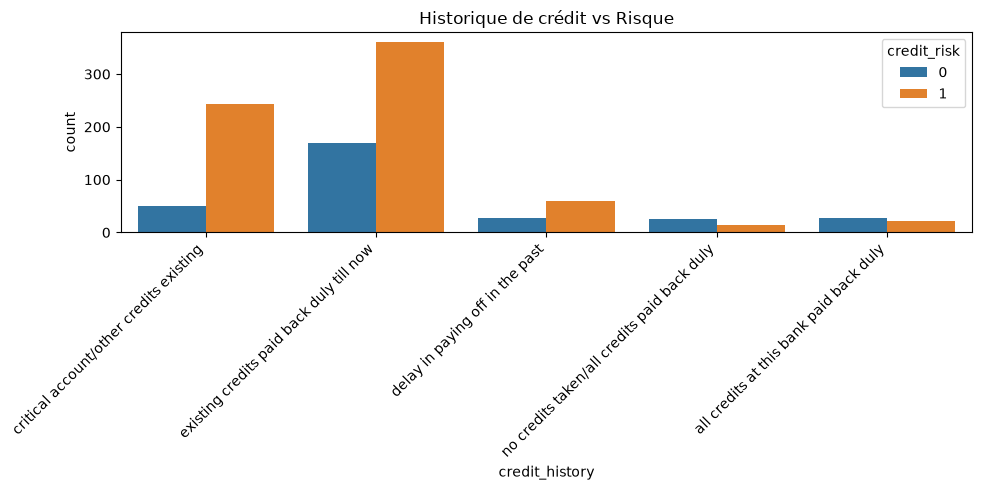

In [11]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='credit_history', hue='credit_risk')
plt.title('Historique de crédit vs Risque')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [12]:
X = df.drop('credit_risk', axis=1)
y = df['credit_risk']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 20)
y shape: (1000,)


In [13]:
X_encoded = pd.get_dummies(X, drop_first=True)

print("Forme avant encodage :", X.shape)
print("Forme après encodage :", X_encoded.shape)
X_encoded.head()

Forme avant encodage : (1000, 20)
Forme après encodage : (1000, 48)


,duration,amount,installment_rate,present_residence,age,number_credits,people_liable,status_... >= 200 DM / salary for at least 1 year,status_0 <= ... < 200 DM,status_no checking account,...,property_unknown/no property,other_installment_plans_none,other_installment_plans_stores,housing_own,housing_rent,job_skilled employee/official,job_unemployed/unskilled - non-resident,job_unskilled - resident,telephone_yes,foreign_worker_yes
0,6,1169,4,4,67,2,1,False,False,False,...,False,True,False,True,False,True,False,False,True,True
1,48,5951,2,2,22,1,1,False,True,False,...,False,True,False,True,False,True,False,False,False,True
2,12,2096,2,3,49,1,2,False,False,True,...,False,True,False,True,False,False,False,True,False,True
3,42,7882,2,4,45,1,2,False,False,False,...,False,True,False,False,False,True,False,False,False,True
4,24,4870,3,4,53,2,2,False,False,False,...,True,True,False,False,False,True,False,False,False,True


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (800, 48)
X_test  : (200, 48)
y_train : (800,)
y_test  : (200,)


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("\nRapport de classification :\n", classification_report(y_test, y_pred))

Accuracy : 0.665

Rapport de classification :
               precision    recall  f1-score   support

           0       0.46      0.65      0.54        60
           1       0.82      0.67      0.74       140

    accuracy                           0.67       200
   macro avg       0.64      0.66      0.64       200
weighted avg       0.71      0.67      0.68       200



In [19]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    max_depth=10
)
rf_model.fit(X_train, y_train)  # Random Forest n'a pas besoin de scaling

y_pred_rf = rf_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("\nRapport de classification :\n", classification_report(y_test, y_pred_rf))

Accuracy : 0.7

Rapport de classification :
               precision    recall  f1-score   support

           0       0.50      0.68      0.58        60
           1       0.84      0.71      0.77       140

    accuracy                           0.70       200
   macro avg       0.67      0.70      0.67       200
weighted avg       0.74      0.70      0.71       200



In [20]:
import pandas as pd

importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances_sorted = importances.sort_values(ascending=False)

print(importances_sorted.head(10))

Task was destroyed but it is pending!
task: <Task pending name='Task-172' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\user\Desktop\credit-risk-ai\venv\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-173' coro=<Kernel.shell_main() running at C:\Users\user\Desktop\credit-risk-ai\venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\user\Desktop\credit-risk-ai\venv\Lib\site-packages\zmq\eventloop\zmqstream.py:564]>
C:\Users\user\Desktop\credit-risk-ai\venv\Lib\site-packages\sklearn\utils\parallel.py:161: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  for k, v in zip(warning_filter_keys, filter_args)
Task was destroyed but it is pending!
task: <Task pending name='Task-173' coro=<Kernel.shell_main() running at C:\Users\user\Desktop\credit-risk-ai\venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


status_no checking account                                0.117511
amount                                                    0.097427
duration                                                  0.089150
age                                                       0.082827
credit_history_critical account/other credits existing    0.035257
installment_rate                                          0.034343
present_residence                                         0.029195
purpose_car (used)                                        0.027405
other_installment_plans_none                              0.025403
purpose_car (new)                                         0.021847
dtype: float64


In [21]:
import joblib

# Sauvegarder le modèle, le scaler, et la liste des colonnes
joblib.dump(rf_model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(list(X_train.columns), 'columns.pkl')

print("Modèle, scaler et colonnes sauvegardés !")

Modèle, scaler et colonnes sauvegardés !
